# Confidence-band root finder (`find_confidence_band`)

Example: instead of a uniform grid, locate the band edges directly by bracketing + geometric bisection.
Bracket the outer reach with the widest level (2σ); the narrower 1σ / 90% / 2σ edges nest inside that interval.

- `num_pseudo_data`: pseudo-data sample size during bracketing (can be coarse)
- `n_pseudo_edge`: pseudo-data sample size for the edge bisection (larger suppresses cutoff noise)
- `seed`: fixed value makes every evaluation reproducible and stops the bisection from jittering

In [1]:
from neutrino_analysis_band import NeutrinoAnalysis


Optimization Complete.
Minimum chi-squared: 1.2547783418123299e-11
Plot saved as T3/scenario_bkg_a/flux_comparison_bkg_a.pdf


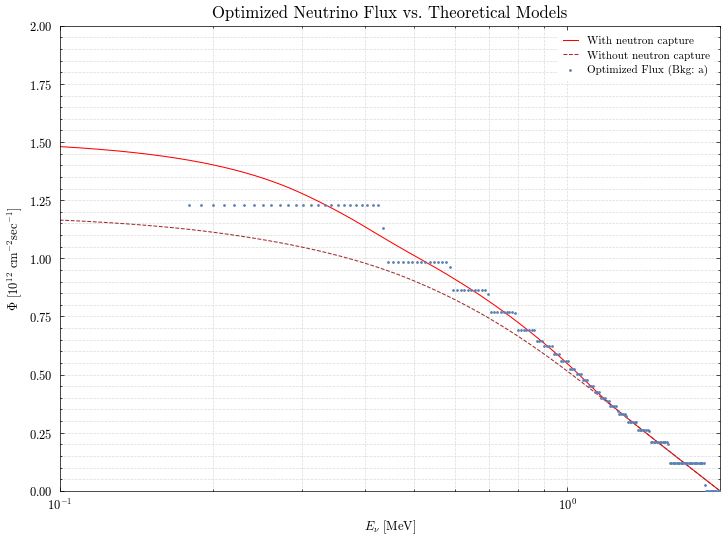

In [2]:
a = NeutrinoAnalysis(background_scenario='a', intervals='180',
                     GeV=0.1e16, solver='osqp', T=3)
a.optimize(a.data_vector)   # Compute the best fit first (populates self.result)
result_a = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_a.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

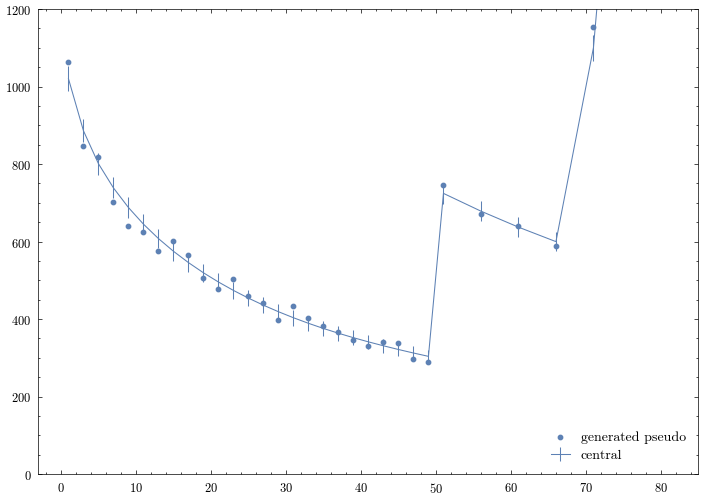

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x = np.array([1., 3., 5., 7., 9., 11., 13., 15., 17., 19., 21., 23.,
                              25., 27., 29., 31., 33., 35., 37., 39., 41., 43.,
                              45., 47., 49., 51., 56., 61., 66., 71., 81., 120.])
plt.figure(figsize=(8, 6))
plt.errorbar(x[:-1], a.generate_pseudo_data(num_pseudo_data=500, seed=None, x=None)[0][:], yerr = np.sqrt(a.generate_pseudo_data(num_pseudo_data=500, seed=None, x=None)[0][:]), label = 'central')
for i in range(1):
    plt.scatter(x[:-1], a.generate_pseudo_data(num_pseudo_data=500, seed=None, x=None)[1][i], s = 10, label = 'generated pseudo')
plt.ylim(0, 1200)
plt.legend(loc = 'lower right', fontsize = 10)

Plot saved as T3/scenario_bkg_a/pseudo_vs_true_bins_bkg_a.pdf


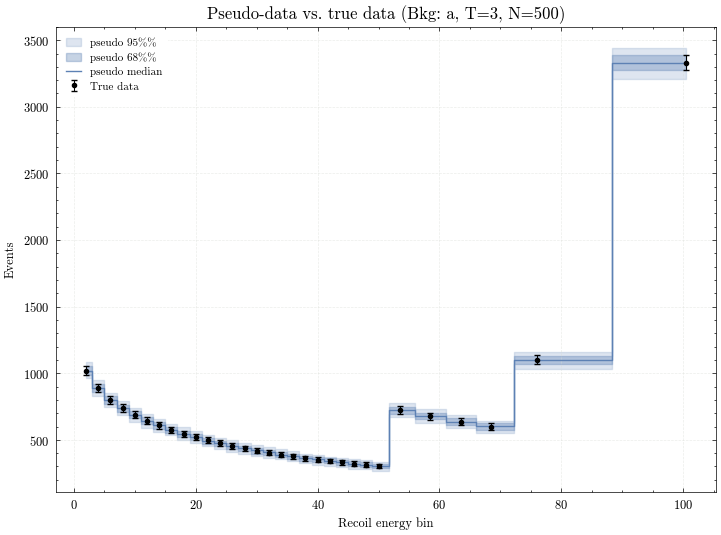

In [ ]:
a.plot_pseudo_data_bins(num_pseudo_data=500, seed=None,regenerate=False, show_lines=False, save=True, fname=None)

## Save bands for several indices and overlay them

1. Run `find_and_save_band` per index and save one JSON file per index under `bands/`.
2. Load the saved files with `plot_flux_with_bands` and overlay each index's band as an error bar on top of the `optimize` flux scatter.

`save_band` / `load_band` use a human-readable JSON format. The band centre is the saved `self.result.x[index]`, so it lines up exactly with the scatter from the same `optimize` result.

In [ ]:
# Saved automatically under the T-prefixed folder (outdir can be omitted)
# → T3/scenario_bkg_flat/bands/band_bkgflat_idx000.json

# Build bands for several indices and save one file per index
# Destination: ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [0, 1, 2, 3, 4, 5, 8, 13, 16, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 167]     # Indices to run

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='T3/scenario_bkg_a/bands',
        levels=(0.678, 0.954),
        num_pseudo_data=50,
        n_pseudo_edge=500,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=1,
        verbose=True,
    )

Plot saved as T3/scenario_bkg_a/flux_with_bands_bkg_a.pdf


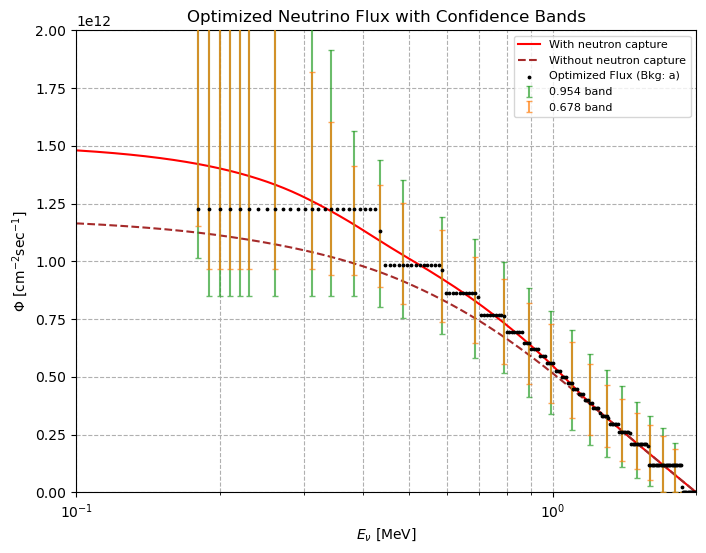

In [6]:
# Load the saved bands and overlay them on the optimize result
# band_files can be a glob pattern or an explicit list
a.plot_flux_with_bands(
    f'T3/scenario_bkg_a/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # Levels to plot (omit to show all saved levels)
    save=True,
    ylim=(0, 3e13),                # So the high-flux tail is visible
)
import matplotlib.pyplot as plt
#plt.yscale('log')
plt.ylim(0, 2e12)
plt.show()

Plot saved as T3/scenario_bkg_a/flux_with_bands_bkg_a.pdf


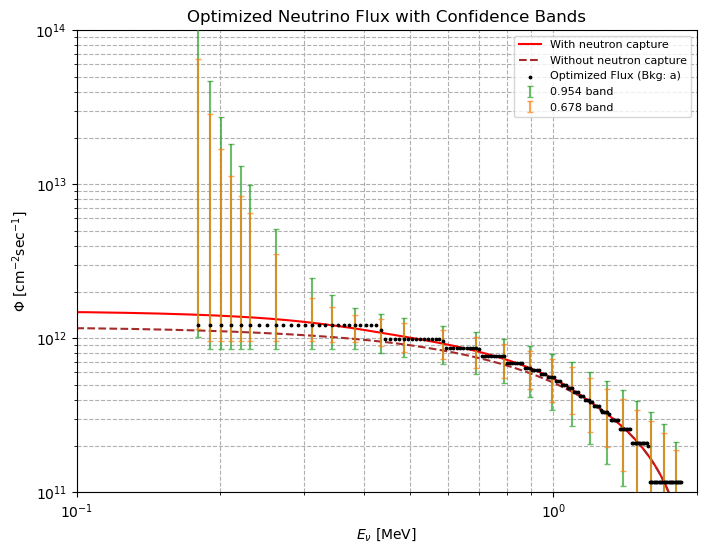

In [7]:
# Load the saved bands and overlay them on the optimize result
# band_files can be a glob pattern or an explicit list
a.plot_flux_with_bands(
    f'T3/scenario_bkg_a/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # Levels to plot (omit to show all saved levels)
    save=True,
    ylim=(0, 3e13),                # So the high-flux tail is visible
)
import matplotlib.pyplot as plt
plt.yscale('log')
plt.ylim(1e11, 1e14)
plt.show()